# Presentado por: 
Eduardo Pérez Cárdenas

##### 1. fft:
Resuelve la ecuación de Poisson para en potencial gravitacional en el espacio de las frecuencias para reducir el tiempo de cómputo.

##### 2. numba:
Compila bucles lentos de Python (for) para acelerar los esquemas de asignación de masa de las partículas debido a que se debe transformar partículas contínuas a una cuadrícula discreta.

##### 2. colossus.cosmology: 
Fija los parámetros cosmológicos de Planck 2018 para obtener la historia de expansión y el espectro de potencias sin integrar manualmente las ecuaciones diferenciales de Friedmann.

In [1]:
import numpy as np
from scipy.fft import fftn, ifftn
from numba import njit, prange
from colossus.cosmology import cosmology

# 1. Cosmological Background Setup
cosmo = cosmology.setCosmology('planck18')

# 2. Domain and resolution definitions
L = 50     # Comoving box size in Mpc/h
N_p = 32   # Number of particles per dimension (32^3)
N_g = 64   # Number of grid cells per dimension (64^3)
dx = L/N_g # Grid spatial resolution

# Integration boundaries
z_start = 30 #High starting redshift to prevent 1LPT transients
z_end = 0
steps = 50

# 3. Unperturbed Lagrangia Lattice: Creating a 3D grid of tracer particles
q_1d = np.linspace(0,L,N_p, endpoint=False)
qx, qy, qz = np.meshgrid(q_1d, q_1d, q_1d, indexing='ij')
#print(qx)
#print(qx.flatten())
q_lattice = np.vstack([qx.flatten(), qy.flatten(), qz.flatten()]).T
#print(q_lattice)

print(f"Cosmología: {cosmo.name}. Lattice: {len(q_lattice)} particulas creadas.")

Cosmología: planck18. Lattice: 32768 particulas creadas.


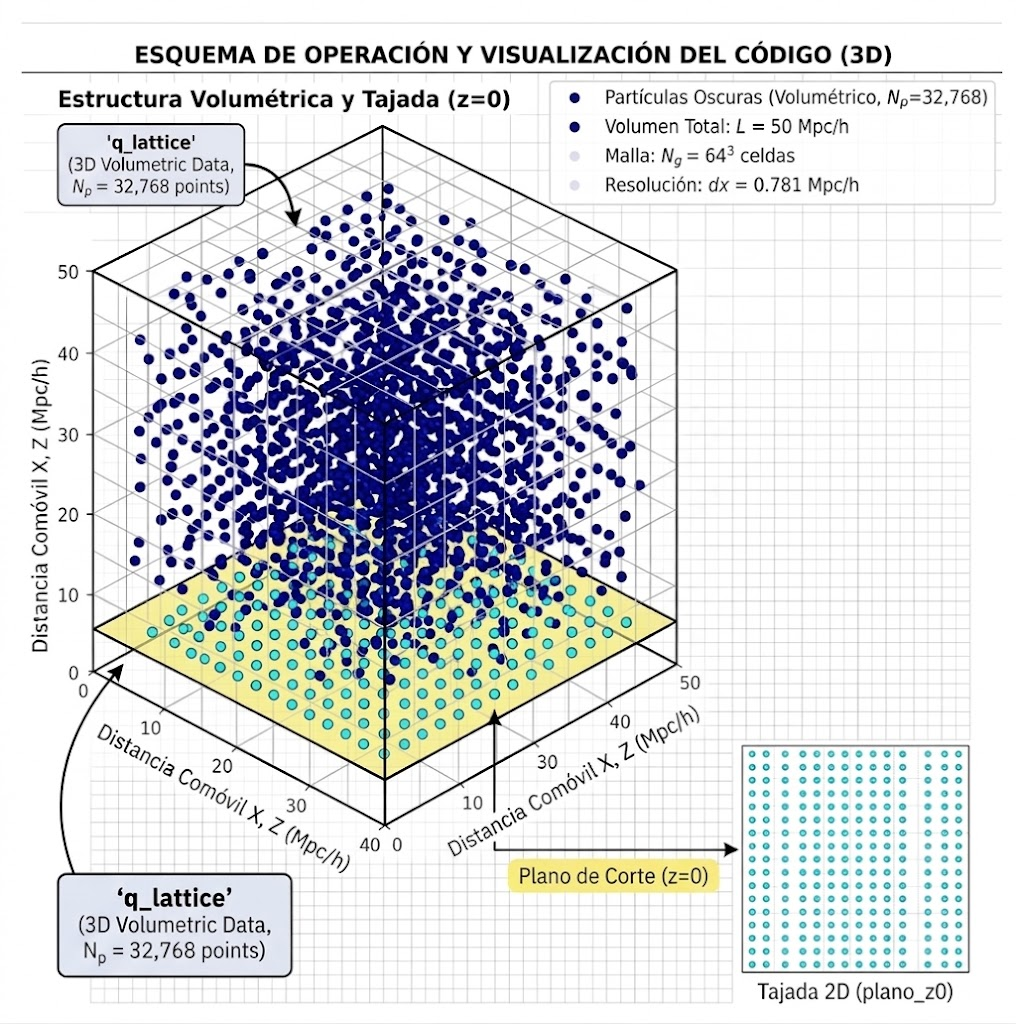

### Espectro de Eisenstein & Hu: 
Genera el espectro de potencias de materia teórico que define la amplitud de las perturbaciones iniciales del universo.   

### Malla de Fourier: 
Crea una cuadrícula tridimensional de números de onda ($k$) para aislar y resolver los modos de frecuencia.   

### Campo Aleatorio Gaussiano: 
Asigna amplitudes y fases aleatorias a la malla espacial, garantizando que la materia oscura colapse formando la red cósmica en lugar de cúmulos uniformes. 

In [2]:
#Zeldovich Initial Conditions Generation
#Construct the 3D wavenumber grid for Fourier space oprations
k_1d = np.fft.fftfreq(N_g, d=dx)*2*np.pi
kx, ky, kz = np.meshgrid(k_1d,k_1d,k_1d, indexing='ij')
#print(kx)

#Squared magnitude of the wavevectors
k_sq = kx**2 + ky**2 + kz**2
#print(k_sq)
k_sq[0,0,0] = 1 #Isolated the DC mode to prevent division vy zero
k_mag = np.sqrt(k_sq)
#print(k_mag)

#Retrieve the theoretical Einstein and Hu Matter Power Spectrum P(k)
#Evaluated at z=0 (will be scaled back to z_start using linear growth factor later)
Pk = cosmo.matterPowerSpectrum(k_mag, model='eisenstein98')
Pk[0,0,0] = 0.0 #Enforce global mass conservation (mean density perturbation = 0)
#print(Pk)

#Synthesize a Gaussian Random Field for the initial density contrast
np.random.seed(42)
real_part = np.random.normal(0, 1, k_mag.shape)
imag_part = np.random.normal(0, 1, k_mag.shape)

#Scale the random Gaussian noise by the theoretical power spectrum
delta_k = (real_part + 1j*imag_part)*np.sqrt(Pk/2.0)
delta_k[0,0,0] = 0.0

print(f"Campo de densidad lineal generado en el espacio de Fourier")
print(f"Dimensiones de la malla: {delta_k.shape}")


Campo de densidad lineal generado en el espacio de Fourier
Dimensiones de la malla: (64, 64, 64)


### Campo de Desplazamiento: 
Convierte el contraste de densidad en el espacio de Fourier a vectores de desplazamiento físico tridimensionales utilizando la Aproximación de Zel'dovich de primer orden (1LPT).   

### Posiciones Eulerianas: 

Desplaza las partículas de materia oscura desde su cuadrícula original hacia las zonas de sobredensidad, escalando la amplitud por el factor de crecimiento cosmológico $D_+(t)$.   

### Velocidades Peculiares Iniciales: 

Asigna el estado cinemático inicial de las partículas en proporción directa a sus desplazamientos espaciales, absorbiendo el flujo de Hubble local.

In [5]:
# 3. Zeldovich Approximation (1LPT) Displacements
# Calculate the displacement field in Fourier space: Psi_k = i * k / k^2 * delta_k
psi_x_k = 1j * (kx / k_sq) * delta_k
psi_y_k = 1j * (ky / k_sq) * delta_k
psi_z_k = 1j * (kz / k_sq) * delta_k

# Zero out the DC mode to prevent unphysical bulk flows
psi_x_k[0, 0, 0] = 0.0
psi_y_k[0, 0, 0] = 0.0
psi_z_k[0, 0, 0] = 0.0

# Transform back to real configuration space via IFFT (Returns shape: N_g x N_g x N_g)
psi_x_grid = np.real(ifftn(psi_x_k))
psi_y_grid = np.real(ifftn(psi_y_k))
psi_z_grid = np.real(ifftn(psi_z_k))

# Subsample the 64^3 displacement grid to match the 32^3 Lagrangian particle lattice
# Since N_g = 2 * N_p, every second grid point perfectly aligns with a particle's initial position
psi_x = psi_x_grid[::2, ::2, ::2].flatten()
psi_y = psi_y_grid[::2, ::2, ::2].flatten()
psi_z = psi_z_grid[::2, ::2, ::2].flatten()

# Retrieve cosmological growth parameters at z_start
D_plus = cosmo.growthFactor(z_start)
f_growth = cosmo.growthRate(z_start)
H_a = cosmo.Hz(z_start) / (1.0 + z_start) # Hubble parameter H(z) / a

# Calculate final Eulerian comoving positions
pos_x = q_lattice[:, 0] + D_plus * psi_x
pos_y = q_lattice[:, 1] + D_plus * psi_y
pos_z = q_lattice[:, 2] + D_plus * psi_z
pos = np.vstack([pos_x, pos_y, pos_z]).T

# Enforce periodic boundary conditions wrapping around [0, L)
pos = np.mod(pos, L)-

# Calculate initial comoving peculiar velocities
vel_x = (1.0 / (1.0 + z_start)) * H_a * f_growth * D_plus * psi_x
vel_y = (1.0 / (1.0 + z_start)) * H_a * f_growth * D_plus * psi_y
vel_z = (1.0 / (1.0 + z_start)) * H_a * f_growth * D_plus * psi_z
vel = np.vstack([vel_x, vel_y, vel_z]).T

print(f"Condiciones de Zel'dovich aplicadas exitosamente.")
print(f"Dimensiones de posiciones: {pos.shape}, Dimensiones de velocidades: {vel.shape}")

AttributeError: 'Cosmology' object has no attribute 'growthRate'